### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

### Loading Dataset

In [3]:
data = pd.read_csv("Makaan_Properties_Buy.csv",encoding='latin1')
data.head()

,Property_Name,Property_id,Property_type,Property_status,Price_per_unit_area,Posted_On,Project_URL,builder_id,Builder_name,Property_building_status,...,is_furnished,listing_domain_score,is_plot,is_RERA_registered,is_Apartment,is_ready_to_move,is_commercial_Listing,is_PentaHouse,is_studio,Listing_Category
0,Arkiton Luxe,15446514,Apartment,Under Construction,"4,285",1 day ago,https://www.makaan.com/ahmedabad/arkiton-life-...,100563465.0,Arkiton life Space,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
1,Keshav Akshar Ocean Pearl,15367414,Apartment,Under Construction,"7,000",2 days ago,https://www.makaan.com/ahmedabad/keshav-naraya...,100009433.0,Keshav Narayan Group,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
2,Vishwa Opulence,14683118,Apartment,Ready to move,"5,752",2 days ago,https://www.makaan.com/ahmedabad/vishwa-develo...,100207731.0,Vishwa Developers Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
3,Satyam Sarjan,5476295,Apartment,Ready to move,"2,486",5 days ago,https://www.makaan.com/ahmedabad/satyam-develo...,101303.0,Satyam Developers,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
4,Navkar Sunflower,15477040,Apartment,Under Construction,"5,324",8 days ago,https://www.makaan.com/ahmedabad/navkar-buildc...,1484209.0,Navkar Buildcon Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell


### Data Understanding

In [4]:
data.shape

(332096, 32)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332096 entries, 0 to 332095
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Property_Name             217826 non-null  object 
 1   Property_id               332096 non-null  int64  
 2   Property_type             332096 non-null  object 
 3   Property_status           271654 non-null  object 
 4   Price_per_unit_area       332096 non-null  object 
 5   Posted_On                 332096 non-null  object 
 6   Project_URL               332096 non-null  object 
 7   builder_id                149978 non-null  float64
 8   Builder_name              149978 non-null  object 
 9   Property_building_status  332096 non-null  object 
 10  City_id                   332096 non-null  int64  
 11  City_name                 332096 non-null  object 
 12  No_of_BHK                 332096 non-null  object 
 13  Locality_ID               332096 non-null  i

In [6]:
data['City_name'].value_counts()

City_name
Mumbai       94339
Chennai      42441
Hyderabad    42344
Bangalore    40463
Lucknow      40380
Delhi        37198
Kolkata      22981
Ahmedabad    11950
Name: count, dtype: int64

### Data Cleaning

In [7]:
cols_to_drop = [
    'Property_id', 'Project_URL', 'builder_id', 'Builder_name', 
    'Property_Name', 'description', 'Locality_ID', 'Sub_urban_ID', 
    'Property_status', 'Posted_On', 'City_id', 'is_commercial_Listing',
    'Listing_Category', 'is_plot' , 'is_Apartment', 'Longitude', 'Latitude'
]

data = data.drop(columns=cols_to_drop)

print(f"Remaining columns: {data.columns.tolist()}")
print(f"New shape: {data.shape}")

Remaining columns: ['Property_type', 'Price_per_unit_area', 'Property_building_status', 'City_name', 'No_of_BHK', 'Locality_Name', 'Price', 'Size', 'Sub_urban_name', 'is_furnished', 'listing_domain_score', 'is_RERA_registered', 'is_ready_to_move', 'is_PentaHouse', 'is_studio']
New shape: (332096, 15)


In [8]:
rename_dict = {
    'Price_per_unit_area': 'price_per_sqft',
    'City_name': 'city',
    'No_of_BHK': 'bhk',
    'Locality_Name': 'locality',
    'Size': 'area_sqft',
    'Sub_urban_name': 'sub_urban',
    'listing_domain_score': 'trust_score'
}

data = data.rename(columns=rename_dict)

print("New Column Names:")
print(data.columns.tolist())

New Column Names:
['Property_type', 'price_per_sqft', 'Property_building_status', 'city', 'bhk', 'locality', 'Price', 'area_sqft', 'sub_urban', 'is_furnished', 'trust_score', 'is_RERA_registered', 'is_ready_to_move', 'is_PentaHouse', 'is_studio']


In [9]:
bool_cols = ['is_RERA_registered', 'is_ready_to_move', 'is_PentaHouse', 'is_studio']
data[bool_cols] = data[bool_cols].astype(int)

In [10]:
data = data.copy()

data['bhk'] = pd.to_numeric(data['bhk'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
data['area_sqft'] = pd.to_numeric(data['area_sqft'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0], errors='coerce')

for col in ['Price', 'price_per_sqft']:
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', ''), errors='coerce')

In [11]:
data.isnull().sum()

Property_type               0
price_per_sqft              0
Property_building_status    0
city                        0
bhk                         0
locality                    2
Price                       0
area_sqft                   0
sub_urban                   0
is_furnished                0
trust_score                 0
is_RERA_registered          0
is_ready_to_move            0
is_PentaHouse               0
is_studio                   0
dtype: int64

In [12]:
data = data.dropna()  

In [13]:
data = data[data['Price'] > 0]

### Feature Engineering

In [14]:
locality_counts = data['locality'].value_counts()
top_localities = locality_counts[locality_counts > 20].index
data['locality'] = data['locality'].apply(lambda x: x if x in top_localities else 'Other')

In [15]:
data['locality'].nunique()

1375

In [16]:
data['Price'] = data['Price'] / 100000

### Outlier Removal

In [17]:
q_low = data['Price'].quantile(0.01)
q_high = data['Price'].quantile(0.99)
a_low = data['area_sqft'].quantile(0.01)
a_high = data['area_sqft'].quantile(0.99)

data = data[(data['Price'] > q_low) & (data['Price'] < q_high)]
data = data[(data['area_sqft'] > a_low) & (data['area_sqft'] < a_high)]

In [18]:
data.shape

(316242, 15)

In [19]:
data['city'].value_counts()

city
Mumbai       91634
Chennai      41644
Hyderabad    41303
Bangalore    40062
Lucknow      34627
Delhi        33310
Kolkata      22370
Ahmedabad    11292
Name: count, dtype: int64

### Inconsistent Data Removal

In [20]:
expected_price = data['area_sqft'] * data['price_per_sqft']
expected_price_lakhs = expected_price / 100000
error = abs(data['Price'] - expected_price_lakhs) / data['Price'] * 100

inconsistent = data[error > 1]
print("Inconsistent rows:", len(inconsistent))

Inconsistent rows: 1106


In [21]:
data = data[error < 1]

inconsistent = data.loc[error > 1]
print("Inconsistent rows:", len(inconsistent))

Inconsistent rows: 0


### Visualisation

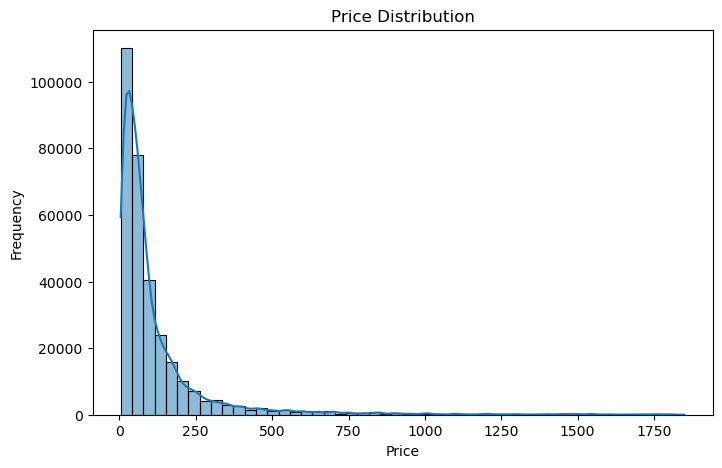

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data['Price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

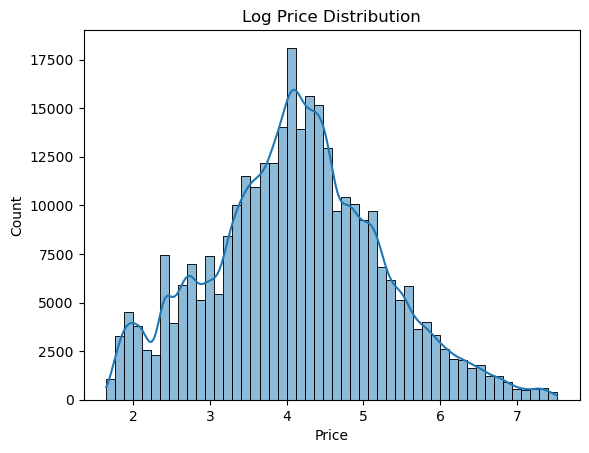

In [23]:
sns.histplot(np.log1p(data['Price']), bins=50, kde=True)
plt.title("Log Price Distribution")
plt.show()

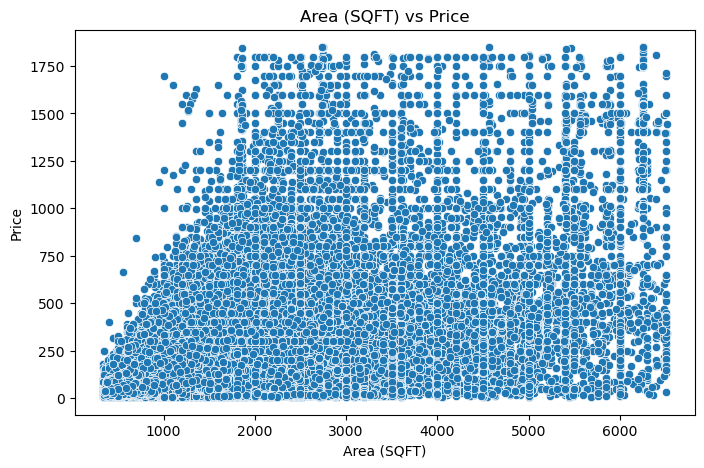

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area_sqft', y='Price', data=data)
plt.title("Area (SQFT) vs Price")
plt.xlabel("Area (SQFT)")
plt.ylabel("Price")
plt.show()

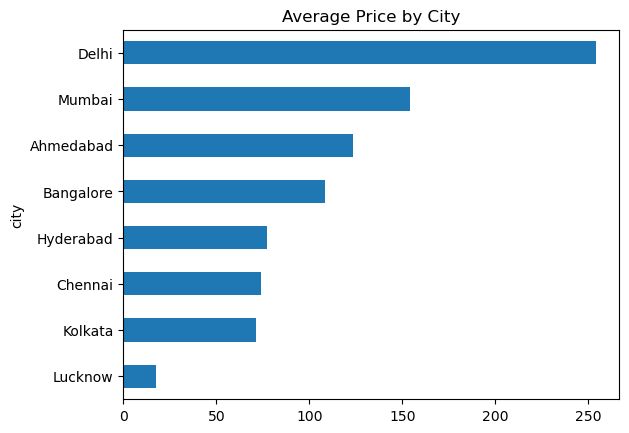

In [54]:
data.groupby('city')['Price'].mean().sort_values().plot(kind='barh')
plt.title("Average Price by City")
plt.show()

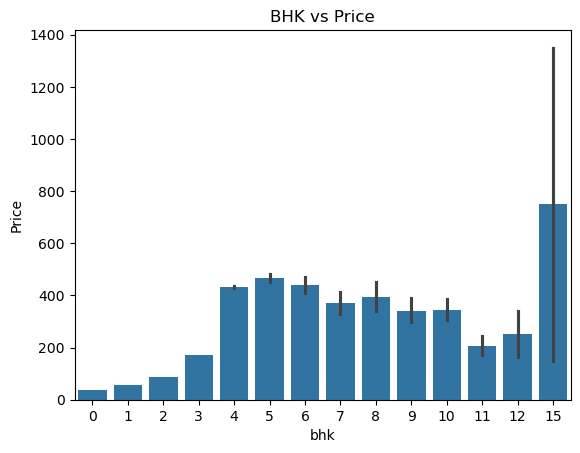

In [26]:
sns.barplot(x='bhk', y='Price', data=data)
plt.title("BHK vs Price")
plt.show()

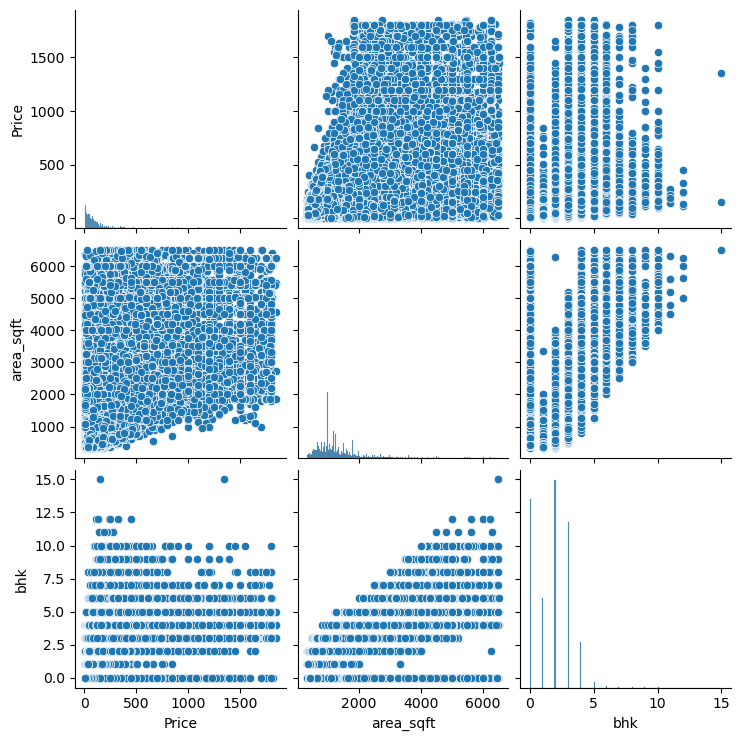

In [27]:
sns.pairplot(data[['Price','area_sqft','bhk']])
plt.show()

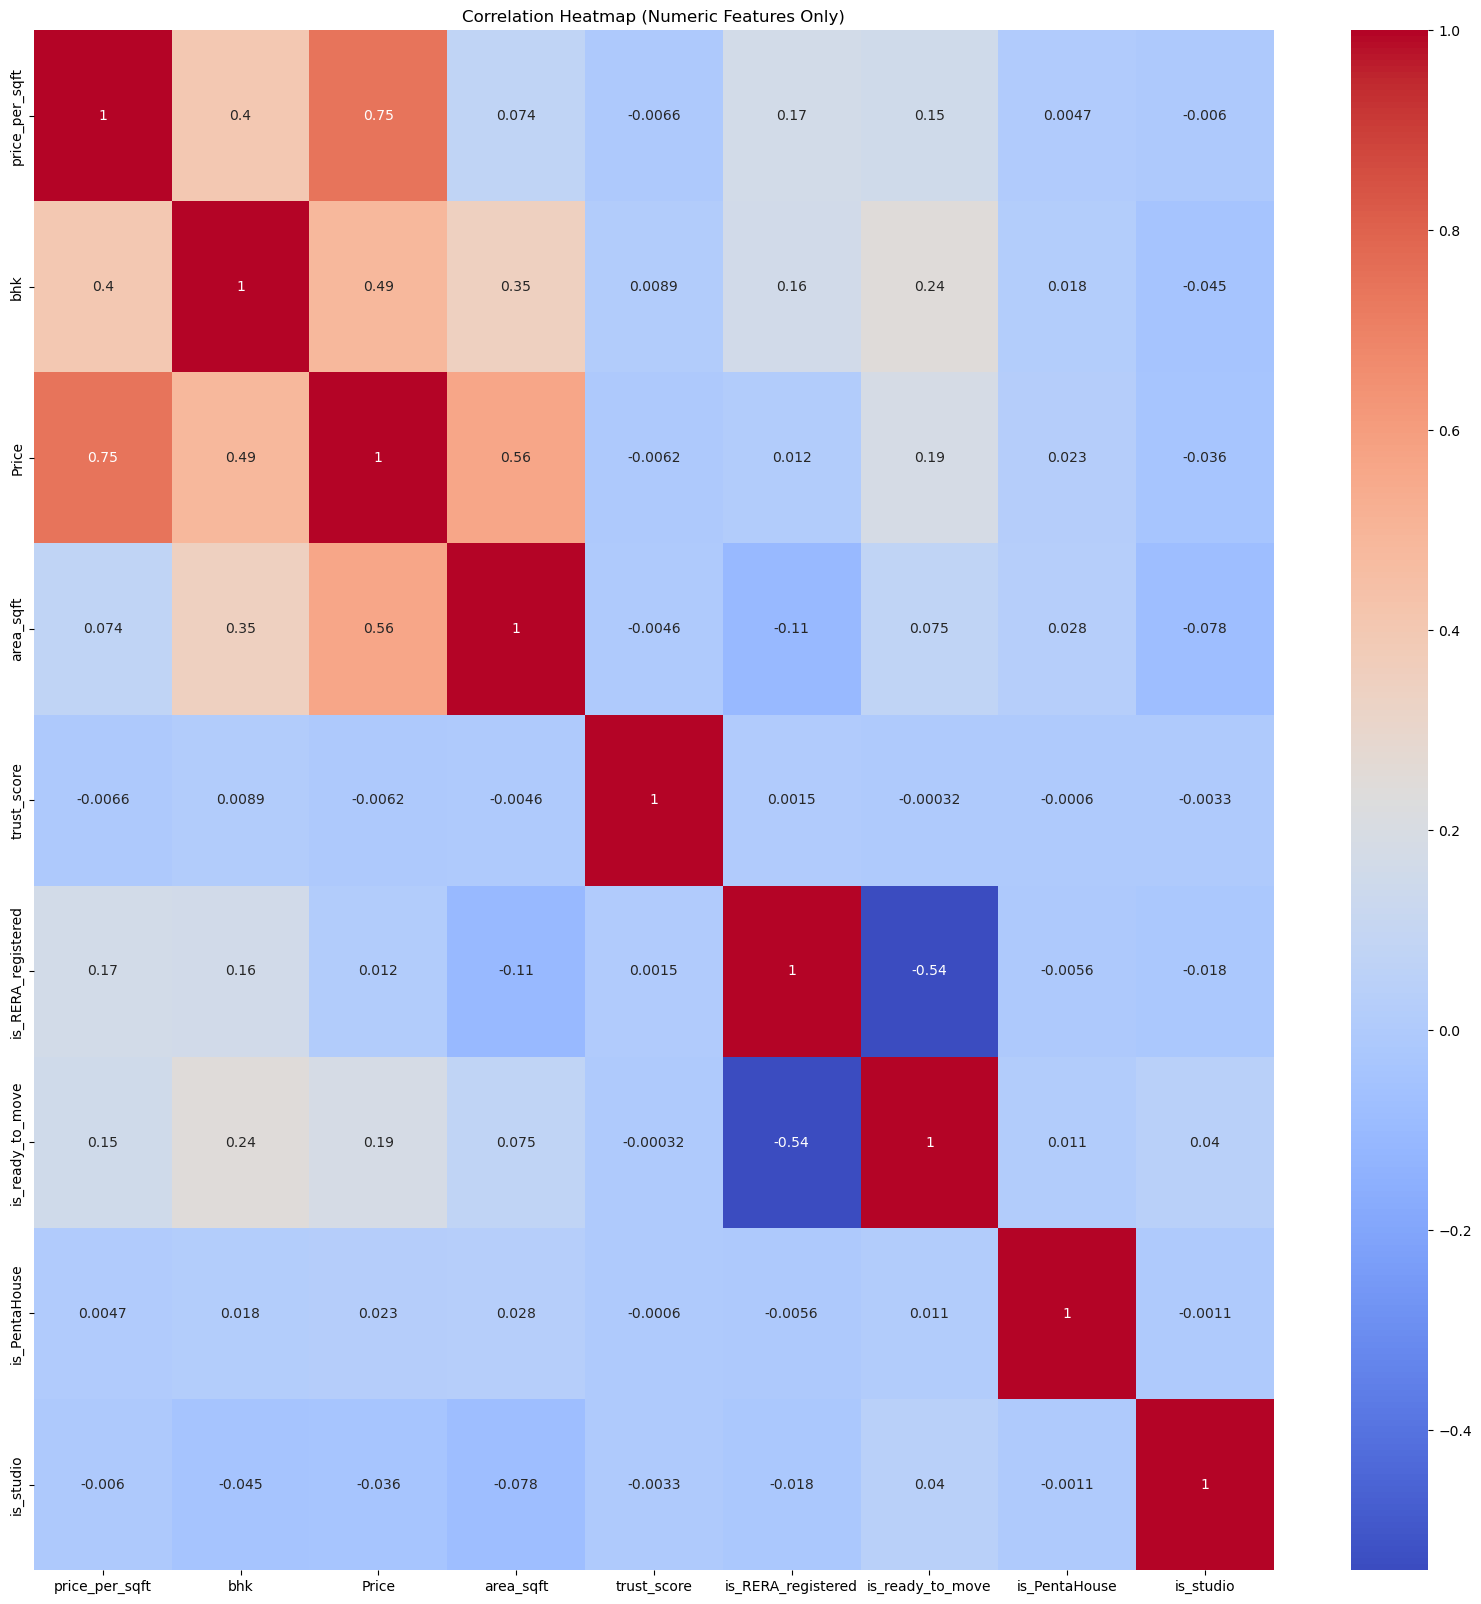

In [28]:
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(20, 20))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [29]:
data.head()

,Property_type,price_per_sqft,Property_building_status,city,bhk,locality,Price,area_sqft,sub_urban,is_furnished,trust_score,is_RERA_registered,is_ready_to_move,is_PentaHouse,is_studio
0,Apartment,4285,ACTIVE,Ahmedabad,3,Bopal,75.0000,1750,Ahmedabad West,Unfurnished,4.0,1,0,0,0
1,Apartment,7000,ACTIVE,Ahmedabad,4,Ambli,236.8800,3384,Ahmedabad West,Unfurnished,4.0,1,0,0,0
2,Apartment,5752,ACTIVE,Ahmedabad,3,Other,132.0084,2295,Ahmedabad West,Unfurnished,4.0,0,1,0,0
3,Apartment,2486,ACTIVE,Ahmedabad,2,Changodar,22.8300,918,Ahmedabad South,Unfurnished,4.0,0,1,0,0
4,Apartment,5324,ACTIVE,Ahmedabad,3,Shilaj,93.7100,1760,Ahmedabad West,Unfurnished,4.0,1,0,0,0


### Data Spiliting

In [30]:
X = data.drop(['Price','price_per_sqft'], axis=1)
y = data['Price']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
print(X_train.dtypes)

Property_type                object
Property_building_status     object
city                         object
bhk                           int64
locality                     object
area_sqft                     int64
sub_urban                    object
is_furnished                 object
trust_score                 float64
is_RERA_registered            int32
is_ready_to_move              int32
is_PentaHouse                 int32
is_studio                     int32
dtype: object


### Encoding

In [33]:
locality_mean = X_train.join(y_train).groupby('locality')['Price'].mean()
X_train['locality'] = X_train['locality'].map(locality_mean)
X_test['locality'] = X_test['locality'].map(locality_mean)
X_test['locality'] = X_test['locality'].fillna(X_train['locality'].mean())

In [34]:
suburban_mean = X_train.join(y_train).groupby('sub_urban')['Price'].mean()
X_train['sub_urban'] = X_train['sub_urban'].map(suburban_mean)
X_test['sub_urban'] = X_test['sub_urban'].map(suburban_mean)
X_test['sub_urban'] = X_test['sub_urban'].fillna(X_train['sub_urban'].mean())

In [35]:
X_train = X_train.drop(columns=["Locality", "Suburban"], errors="ignore")
X_test = X_test.drop(columns=["Locality", "Suburban"], errors="ignore")

In [36]:
cat_cols = ['Property_type', 'Property_building_status', 'is_furnished', 'city']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)
X_train_cat = pd.DataFrame(X_train_cat, columns=ohe_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=ohe_cols, index=X_test.index)

X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test = pd.concat([X_test, X_test_cat], axis=1)

In [37]:
X_train.head()

,bhk,locality,area_sqft,sub_urban,trust_score,is_RERA_registered,is_ready_to_move,is_PentaHouse,is_studio,Property_type_Independent Floor,...,Property_building_status_UNVERIFIED,is_furnished_Semi-Furnished,is_furnished_Unfurnished,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Lucknow,city_Mumbai
57334,2,63.642344,940,81.056965,4.0,0,1,0,0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
110044,4,176.781172,1950,159.744957,4.0,0,1,0,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
43101,3,105.600906,1582,152.239039,4.0,0,1,0,0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
134180,0,23.499612,1800,33.960136,4.0,1,0,0,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
108616,3,202.283529,2200,159.744957,4.0,0,1,0,0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Data Scaling

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### Models Selection Using K Fold Validation

In [39]:
lr = LinearRegression()
ridge = Ridge()
lasso = Lasso(max_iter=100000, alpha=0.1)
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)
cb = CatBoostRegressor(verbose=0,random_state=42)
lgbm = LGBMRegressor(verbose=-1,random_state=42)

models = {
    "Linear Regression": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XG Boost": xgb,
    "CatBoost": cb,
    "LightGBM": lgbm,
}

In [40]:
for name, model in models.items():
    if name in ["Linear Regression", "Ridge", "Lasso"]: 
        scores = cross_val_score(model, X_train_scaled, y_train_log, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X_train, y_train_log, cv=5, scoring='r2')
    
    print(f"{name} CV R2:", scores.mean())

Linear Regression CV R2: 0.8144563957438763
Ridge CV R2: 0.8144563975389602
Lasso CV R2: 0.7715862133679476
Decision Tree CV R2: 0.9058353234024128
Random Forest CV R2: 0.9349059908097364
Gradient Boosting CV R2: 0.8886662870619546
XG Boost CV R2: 0.9237831597170313
CatBoost CV R2: 0.9245039635924257
LightGBM CV R2: 0.9141627771771332


### HyperTunning Parameters

No hypertunning of parameters needed

### Stacking of Models

In [41]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('lr', lr),
    ('xgb', xgb ),
    ('cb', cb)
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10)
)

scores = cross_val_score(stack, X_train, y_train, cv=5, scoring='r2')
print("CV R2:", scores.mean())

CV R2: 0.8881901383631898


### Training Best Models for testing

In [42]:
rf.fit(X_train,y_train_log)
xgb.fit(X_train,y_train_log)
cb.fit(X_train,y_train_log)
lgbm.fit(X_train,y_train_log)
stack.fit(X_train,y_train_log)

predictions = {
    "Random Forest": rf.predict(X_test),
    "XG Boost": xgb.predict(X_test),
    "CatBoost": cb.predict(X_test),
    "LightGBM": lgbm.predict(X_test),
    "Stack": stack.predict(X_test)
}

### Models Evaluation

In [43]:
results = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test_log, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_log, y_pred))
    r2 = r2_score(y_test_log, y_pred)  
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

           Model       MAE      RMSE        R2
0  Random Forest  0.166470  0.280020  0.935846
4          Stack  0.206330  0.303055  0.924857
2       CatBoost  0.208564  0.305007  0.923886
1       XG Boost  0.209122  0.306774  0.923002
3       LightGBM  0.228257  0.327549  0.912220


In [44]:
results_actual = []

for name, y_pred in predictions.items():
    y_pred_actual = np.expm1(y_pred)
    
    mae_actual = mean_absolute_error(y_test, y_pred_actual)
    rmse_actual  = np.sqrt(mean_squared_error(y_test, y_pred_actual))
    r2_actual  = r2_score(y_test, y_pred_actual)
    
    results_actual.append([name, mae_actual , rmse_actual , r2_actual])
    
results_actual_df = pd.DataFrame(results_actual, columns=["Model", "MAE_in_lakhs", "RMSE", "R2"])
results_actual_df = results_actual_df.sort_values(by="R2", ascending=False)

print(results_actual_df)

           Model  MAE_in_lakhs       RMSE        R2
0  Random Forest     19.383718  56.852727  0.899542
4          Stack     23.825253  62.562801  0.878349
1       XG Boost     24.076092  62.859346  0.877193
2       CatBoost     24.141283  63.019038  0.876569
3       LightGBM     26.116858  66.826665  0.861203


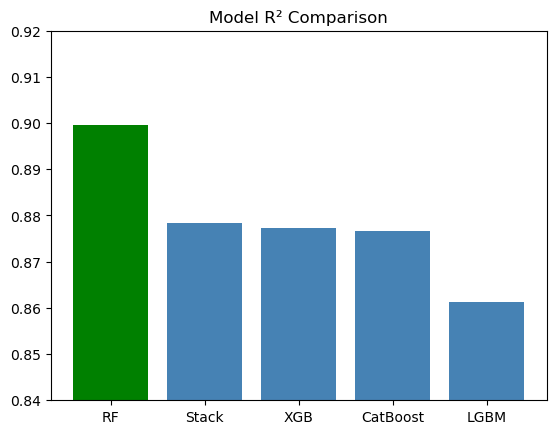

In [48]:
models_r2 = {"RF": 0.8995, "Stack": 0.8783, "XGB": 0.8772, "CatBoost": 0.8766, "LGBM": 0.8612}
plt.bar(models_r2.keys(), models_r2.values(), color=["green","steelblue","steelblue","steelblue","steelblue"])
plt.title("Model R² Comparison")
plt.ylim(0.84, 0.92)
plt.show()

### Making predictions directly by Random Forest

In [45]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
r2  = r2_score(y_test, y_pred)

print("MAE : ", mae)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  19.84717485460314
RMSE :  56.67546621506707
R2 :  0.9001674392171786


### Result Visualization

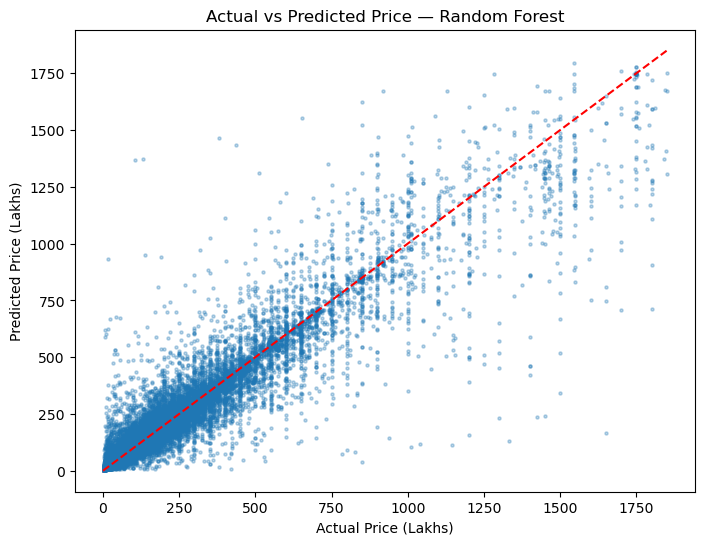

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Price — Random Forest")
plt.show()

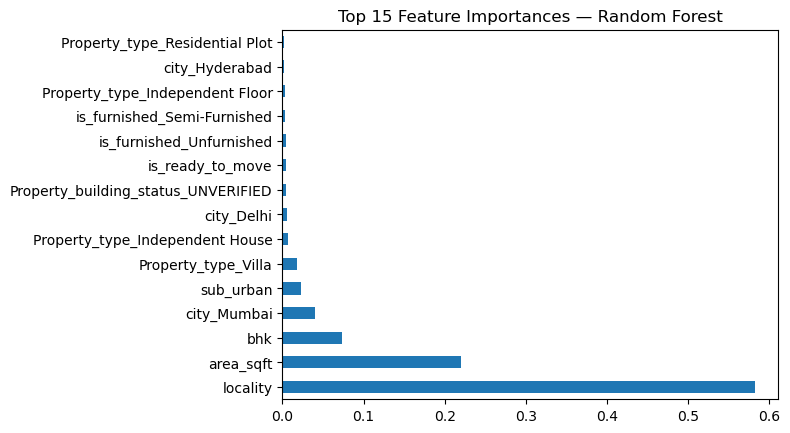

In [49]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).plot(kind='barh')
plt.title("Top 15 Feature Importances — Random Forest")
plt.show()

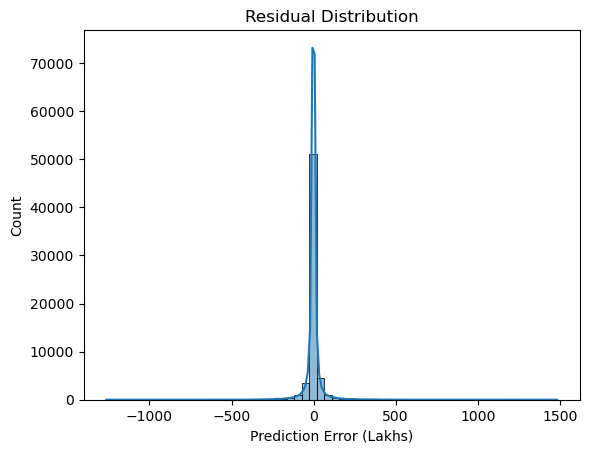

In [51]:
residuals = y_test - y_pred
sns.histplot(residuals, bins=60, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Lakhs)")
plt.show()

### Saving Model pipeline

In [125]:
import pickle, json

# Save model pipeline
pipeline = {
    "model": rf,
    "ohe": ohe,
    "features": X_train.columns.tolist(),
    "locality_mean": locality_mean.to_dict(),
    "suburban_mean": suburban_mean.to_dict()
}

pickle.dump(pipeline, open("pipeline.pkl", "wb"))

# City → Suburban → Locality mapping
city_mapping = {}

for city in data['city'].dropna().unique():
    city_data = data[data['city'] == city]
    sub_map = {}
    
    for sub in city_data['sub_urban'].dropna().unique():
        sub_data = city_data[city_data['sub_urban'] == sub]
        sub_map[sub] = sorted(sub_data['locality'].dropna().unique().tolist())
    
    city_mapping[city] = sub_map

with open("city_mapping.json", "w") as f:
    json.dump(city_mapping, f, indent=4)